# Notebook 02 - Train PPO trên Azure Original Workload

Notebook này train PPO trên workload gốc trích từ Azure Public Dataset để kiểm tra mô hình trên dữ liệu gần nguyên bản.

Các mục tiêu được theo dõi theo đúng yêu cầu đồ án:

- Energy Model (mô hình tiêu thụ năng lượng) với DVFS và trạng thái host Active/Sleep/Off.
- DRL Agent (tác nhân học tăng cường sâu) dùng PPO để quản lý tài nguyên động.
- VM Consolidation (hợp nhất máy ảo) thông qua `vm_snapshots.csv` và placement/migration trong environment.
- Multi-objective Reward (hàm thưởng đa mục tiêu) cân bằng energy, SLA, latency, DVFS, migration, temperature.
- So sánh với baseline (thuật toán đối chứng): Fixed-Keep, RoundRobin, Threshold, BestFit.
- Lưu biểu đồ phục vụ báo cáo: energy saving, PUE, SLA violation, active/sleep/off hosts, DVFS, temperature, migration, dashboard demand-active-energy.

Lưu ý: workload gốc từ Azure trong window 0–90 ngày có xu hướng chủ yếu medium/high demand. Vì vậy kết quả trên notebook này dùng để đánh giá trên trace gốc; phần kiểm tra Dynamic Power Management (quản lý nguồn động) rõ hơn sẽ nằm ở notebook multiphase.


Notebook này dùng `workload_real_original.csv`, tức **Azure original workload (workload gốc từ Azure)**.

Ý nghĩa:

- workload này giữ demand gốc sau bước normalize từ Azure trace;
- dùng chung `vm_snapshots.csv` để giữ cấu trúc VM theo timestep;
- dùng để kiểm tra PPO trên dữ liệu thực tế gần nguyên bản.

Điểm cần nhớ:

- Workload gốc có thể thiếu low demand (tải thấp), nên agent có thể ít cơ hội sleep/off host.
- Không nên kỳ vọng kết quả tiết kiệm năng lượng quá mạnh nếu demand luôn medium/high.
- Kết quả notebook này nên được trình bày như Experiment A: Azure Original Workload.


### Bước 1 - Import thư viện và module từ `src/`

In [1]:
from __future__ import annotations

import os
import sys
import json
import re
from pathlib import Path
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv

try:
    import torch
except Exception:
    torch = None


def find_project_root(start: Path | None = None) -> Path:
    # Tìm project root bằng cách đi ngược lên tới thư mục có `src/` và `data/`.
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "src").exists() and (p / "data").exists():
            return p
    # Fallback cho trường hợp notebook nằm trong notebooks/ và user chạy từ đó.
    return Path("..").resolve()


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.energy_env import CloudEnergyEnv, EnvConfig, load_workload_csv
from src.baselines import (
    FixedPolicy,
    RoundRobinPolicy,
    ThresholdPolicy,
    BestFitPolicy,
)
from src.experiment_reporting import (
    evaluate_policies,
    create_experiment_report,
)


print("PROJECT_ROOT =", PROJECT_ROOT)
print("Import từ src/ thành công.")


PROJECT_ROOT = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project
Import từ src/ thành công.


### Bước 2 - Cấu hình experiment và output folder

Mỗi lần chạy sẽ tự tạo một thư mục mới, ví dụ:

```text
outputs/original/run01_seed42_500000/
outputs/original/run02_seed40_1000000/
```

Trong mỗi run sẽ có:

```text
models/   -> lưu model PPO
traces/   -> lưu trace từng policy theo timestep
summary/  -> lưu bảng kết quả CSV
figures/  -> lưu biểu đồ
logs/     -> lưu config và TensorBoard log
```


In [2]:
EXPERIMENT_KEY = "original"
EXPERIMENT_LABEL = "Experiment A - Azure Original Workload"

WORKLOAD_CSV = PROJECT_ROOT / "data" / "workload_real_original.csv"
VM_SNAPSHOT_CSV = PROJECT_ROOT / "data" / "vm_snapshots.csv"

OUTPUT_BASE_DIR = PROJECT_ROOT / "outputs"
EXPERIMENT_DIR = OUTPUT_BASE_DIR / EXPERIMENT_KEY

# Có thể đổi seed và số timestep trước mỗi lần chạy.
SEED = 42
TOTAL_TIMESTEPS = 500_000
N_ENVS = 4
TRAIN_FROM_SCRATCH = True


def get_next_run_dir(experiment_dir: Path, seed: int, timesteps: int) -> tuple[Path, str]:
    experiment_dir.mkdir(parents=True, exist_ok=True)
    pattern = re.compile(r"run(\d+)_seed\d+_\d+$")
    existing_run_numbers = []

    for p in experiment_dir.iterdir():
        if not p.is_dir():
            continue
        match = pattern.match(p.name)
        if match:
            existing_run_numbers.append(int(match.group(1)))

    next_run_number = max(existing_run_numbers) + 1 if existing_run_numbers else 1
    run_name = f"run{next_run_number:02d}_seed{seed}_{timesteps}"
    return experiment_dir / run_name, run_name


RUN_DIR, RUN_NAME = get_next_run_dir(EXPERIMENT_DIR, SEED, TOTAL_TIMESTEPS)

MODEL_DIR = RUN_DIR / "models"
TRACE_DIR = RUN_DIR / "traces"
SUMMARY_DIR = RUN_DIR / "summary"
FIGURE_DIR = RUN_DIR / "figures"
LOG_DIR = RUN_DIR / "logs"
TB_LOG_DIR = LOG_DIR / "tensorboard"

for d in [MODEL_DIR, TRACE_DIR, SUMMARY_DIR, FIGURE_DIR, LOG_DIR, TB_LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / f"ppo_{EXPERIMENT_KEY}_model"
RESULT_CSV = SUMMARY_DIR / "evaluation_results.csv"
SAVING_CSV = SUMMARY_DIR / "energy_saving_percentages.csv"
RUN_CONFIG_PATH = LOG_DIR / "run_config.json"

print("EXPERIMENT_LABEL =", EXPERIMENT_LABEL)
print("WORKLOAD_CSV =", WORKLOAD_CSV)
print("VM_SNAPSHOT_CSV =", VM_SNAPSHOT_CSV)
print("RUN_DIR =", RUN_DIR)
print("MODEL_PATH =", str(MODEL_PATH) + ".zip")

EXPERIMENT_LABEL = Experiment A - Azure Original Workload
WORKLOAD_CSV = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\workload_real_original.csv
VM_SNAPSHOT_CSV = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\vm_snapshots.csv
RUN_DIR = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\outputs\original\run13_seed42_500000
MODEL_PATH = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\outputs\original\run13_seed42_500000\models\ppo_original_model.zip


### Bước 3 - Load workload và kiểm tra input

- `demand` là nhu cầu CPU đã chuẩn hóa của workload.
- Với workload gốc, có thể không có sẵn cột `phase`; notebook sẽ tự gán phase low / medium / high để phân tích.
- Nếu phase low có ít hoặc bằng 0, đây là đặc điểm của Azure original workload trong window đang xét, không phải lỗi code.


Số timestep: 2160


,timestep,demand,raw_core_demand,active_vm_count
0,0,1.009656,113390.769344,875495
1,1,1.008134,113219.745314,875378
2,2,1.005760,112953.144655,874422
3,3,1.004791,112844.379743,870308
4,4,1.007926,113196.421713,871064


count    2160.000000
mean        0.799255
std         0.087287
min         0.694048
25%         0.733779
50%         0.773989
75%         0.843092
max         1.043675
Name: demand, dtype: float64

,count,min,mean,max
phase,,,,
low,0,NaN,NaN,NaN
medium,783,0.694048,0.721636,0.749976
high,1377,0.750040,0.843392,1.043675


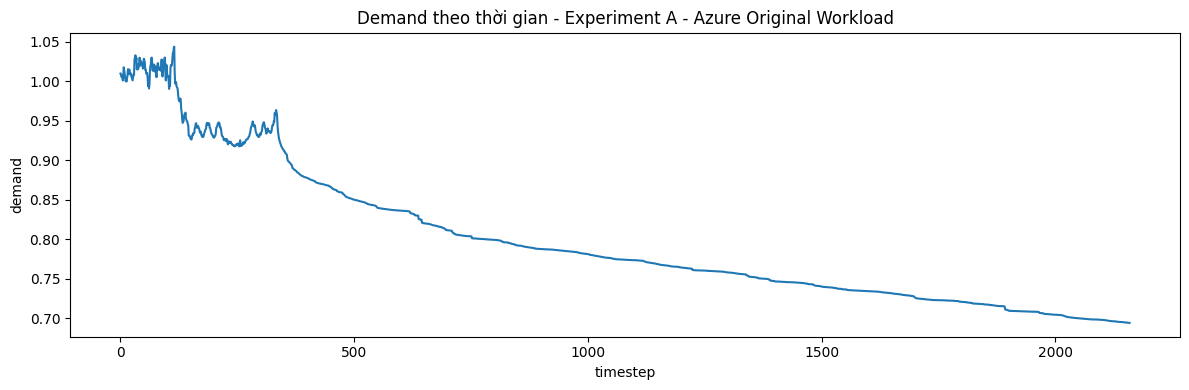

In [3]:
assert WORKLOAD_CSV.exists(), f"Không thấy file workload: {WORKLOAD_CSV}"
assert VM_SNAPSHOT_CSV.exists(), f"Không thấy file vm_snapshots: {VM_SNAPSHOT_CSV}"

workload_df = pd.read_csv(WORKLOAD_CSV)
workload = load_workload_csv(str(WORKLOAD_CSV))

print("Số timestep:", len(workload_df))
display(workload_df.head())
display(workload_df["demand"].describe())

# Nếu workload chưa có phase, tự gán phase để phân tích.
if "phase" not in workload_df.columns:
    workload_df["phase"] = pd.cut(
        workload_df["demand"],
        bins=[0.0, 0.40, 0.75, 2.0],
        labels=["low", "medium", "high"],
        include_lowest=True,
    )

phase_summary = workload_df.groupby("phase", observed=False)["demand"].agg(["count", "min", "mean", "max"])
display(phase_summary)

plt.figure(figsize=(12, 4))
plt.plot(workload_df["timestep"], workload_df["demand"])
plt.title(f"Demand theo thời gian - {EXPERIMENT_LABEL}")
plt.xlabel("timestep")
plt.ylabel("demand")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "input_demand.png", dpi=150)
plt.show()


### Bước 4 - Tạo `EnvConfig` và test environment

`EnvConfig` (cấu hình môi trường) lấy các weight reward mới nhất từ `src.energy_env`. Notebook chỉ override các tham số cần thiết như episode length, seed và đường dẫn `vm_snapshots.csv`.


In [4]:
train_episode_length = 320
# Eval dùng gần toàn bộ workload để so sánh công bằng.
eval_episode_length = len(workload) - 1

reward_overrides = {
    "reward_w_energy": 3.15,

    "reward_w_sla": 4.20,
    "reward_w_latency": 0.14,
    "latency_cap": 3.0,

    "sla_extra_threshold_1": 0.05,
    "sla_extra_penalty_1": 1.00,
    "sla_extra_threshold_2": 0.15,
    "sla_extra_penalty_2": 2.50,
    "sla_penalty_growth_threshold": 0.10,
    "sla_penalty_growth_factor": 5.00,

    "reward_w_dvfs": 1.60,
    "reward_w_dvfs_mismatch": 1.10,

    "reward_w_overprovision": 1.75,
    "reward_w_active_excess": 1.70,
    "reward_w_sleep_excess": 0.25,
    "reward_w_off_bonus": 1.10,

    "reward_w_migration": 0.08,
    "migration_cost": 1.0,
    "reward_w_switch": 0.05,

    "reward_w_temp": 0.18,
    "reward_w_lifetime": 0.07,

    "target_host_util": 0.88,
    "reserve_sleep_hosts": 1,
}

base_config = EnvConfig(
    episode_length=train_episode_length,
    seed=SEED,
    vm_snapshot_path=str(VM_SNAPSHOT_CSV) if VM_SNAPSHOT_CSV.exists() else None,
    **reward_overrides,
)

train_config = base_config
eval_config = replace(base_config, episode_length=eval_episode_length, seed=SEED)

print("train_episode_length =", train_episode_length)
print("eval_episode_length  =", eval_episode_length)
print("vm_snapshot_path     =", train_config.vm_snapshot_path)
print("reward_w_latency    =", train_config.reward_w_latency)
print("latency_cap         =", train_config.latency_cap)
print("reward_w_energy      =", train_config.reward_w_energy)
print("reward_w_sla         =", train_config.reward_w_sla)
print("reward_w_dvfs        =", train_config.reward_w_dvfs)
print("reward_w_dvfs_mismatch =", train_config.reward_w_dvfs_mismatch)
print("reward_w_off_bonus   =", train_config.reward_w_off_bonus)

# Check environment theo chuẩn Gymnasium/SB3.
check_env(CloudEnergyEnv(workload=workload, config=train_config), warn=True)
print("OK: CloudEnergyEnv hợp lệ.")

train_episode_length = 320
eval_episode_length  = 2159
vm_snapshot_path     = C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\data\vm_snapshots.csv
reward_w_latency    = 0.14
latency_cap         = 3.0
reward_w_energy      = 3.15
reward_w_sla         = 4.2
reward_w_dvfs        = 1.6
reward_w_dvfs_mismatch = 1.1
reward_w_off_bonus   = 1.1
OK: CloudEnergyEnv hợp lệ.


### Bước 5 - Chạy thử vài action trước khi train

Mục tiêu là kiểm tra environment có trả về observation (quan sát), reward (phần thưởng), info (thông tin thống kê) ổn không.


In [5]:
env_debug = CloudEnergyEnv(workload=workload, config=train_config)
obs, _ = env_debug.reset(seed=SEED)
print("obs ban đầu shape =", obs.shape)
print("obs ban đầu =", obs)

for action in [0, 4, 2, 5, 1, 3]:
    obs, reward, terminated, truncated, info = env_debug.step(action)
    print(
        f"action={action} reward={reward:.4f} "
        f"demand={info['demand']:.3f} active={info['active_hosts']} "
        f"sleep={info['sleep_hosts']} off={info['off_hosts']} "
        f"dvfs={info['dvfs']:.2f} power={info['power_total']:.2f} sla={info['sla_violation']:.4f}"
    )
    if terminated or truncated:
        break


obs ban đầu shape = (17,)
obs ban đầu = [0.9410471  0.9416136  0.875      0.8333333  0.7486772  0.
 0.13440116 0.02070768 0.125      0.         0.4272823  0.43714207
 0.001      0.         0.01779751 0.00364863 0.        ]
action=0 reward=-3.0302 demand=0.941 active=7 sleep=1 off=0 dvfs=1.00 power=1814.33 sla=0.0000
action=4 reward=-4.3315 demand=0.942 active=7 sleep=1 off=0 dvfs=0.80 power=1542.68 sla=0.1504
action=2 reward=-6.3309 demand=0.943 active=6 sleep=2 off=0 dvfs=0.80 power=1383.54 sla=0.2732
action=5 reward=-6.2882 demand=0.941 active=6 sleep=1 off=1 dvfs=0.80 power=1385.61 sla=0.2717
action=1 reward=-3.9986 demand=0.940 active=7 sleep=0 off=1 dvfs=0.80 power=1577.31 sla=0.1491
action=3 reward=-3.0818 demand=0.938 active=7 sleep=0 off=1 dvfs=1.00 power=1922.07 sla=0.0000


### Bước 6 - Train PPO

PPO (Proximal Policy Optimization – thuật toán học tăng cường sâu) học policy (chính sách hành động) để tối ưu reward đa mục tiêu: energy, SLA, latency, DVFS, migration, temperature, active/sleep/off host.

Với Azure original workload, demand chủ yếu ở medium/high load nên PPO có thể thiên về giữ SLA hơn là sleep/off mạnh. Đây là kết quả có ý nghĩa để so sánh với workload multiphase.


In [6]:
def make_env(rank: int):
    def _init():
        cfg = replace(train_config, seed=SEED + rank)
        return Monitor(CloudEnergyEnv(workload=workload, config=cfg))
    return _init

policy_kwargs = dict(
    net_arch=dict(pi=[128, 128], vf=[128, 128])
)

device = "cpu"
if torch is not None and torch.cuda.is_available():
    device = "cuda"
print("Using device:", device)

# PPO config ưu tiên học nhanh hơn so với bản debug.
# learning_rate cao hơn giúp 500k timestep có tín hiệu học rõ hơn;
# ent_coef giữ exploration (khám phá hành động) để agent thử DVFS_DOWN / SLEEP / POWER_OFF.
ppo_config = {
    "learning_rate": 2.5e-4,
    "n_steps": 512,
    "batch_size": 256,
    "n_epochs": 10,
    "gamma": 0.995,
    "gae_lambda": 0.95,
    "clip_range": 0.20,
    "ent_coef": 0.035,
    "vf_coef": 0.50,
    "max_grad_norm": 0.50,
    "target_kl": 0.025,
}

run_config = {
    "experiment_key": EXPERIMENT_KEY,
    "experiment_label": EXPERIMENT_LABEL,
    "workload_csv": str(WORKLOAD_CSV),
    "vm_snapshot_csv": str(VM_SNAPSHOT_CSV),
    "run_name": RUN_NAME,
    "seed": SEED,
    "total_timesteps": TOTAL_TIMESTEPS,
    "n_envs": N_ENVS,
    "train_episode_length": train_episode_length,
    "eval_episode_length": eval_episode_length,
    "device": device,
    "reward_overrides": reward_overrides,
    "ppo_config": ppo_config,
    "note": "Notebook imports baselines/env/evaluation from src; it does not duplicate baseline algorithms.",
}
RUN_CONFIG_PATH.write_text(json.dumps(run_config, indent=2, ensure_ascii=False), encoding="utf-8")

if TRAIN_FROM_SCRATCH:
    vec_env = DummyVecEnv([make_env(i) for i in range(N_ENVS)])

    model = PPO(
        policy="MlpPolicy",
        env=vec_env,
        policy_kwargs=policy_kwargs,
        verbose=1,
        seed=SEED,
        device=device,
        tensorboard_log=str(TB_LOG_DIR),
        **ppo_config,
    )

    model.learn(total_timesteps=TOTAL_TIMESTEPS)
    model.save(str(MODEL_PATH))
    vec_env.close()
    print("Đã train và lưu model tại:", str(MODEL_PATH) + ".zip")
else:
    model = PPO.load(str(MODEL_PATH) + ".zip", device=device)
    print("Đã load model tại:", str(MODEL_PATH) + ".zip")

Using device: cpu
Using cpu device
Logging to C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\outputs\original\run13_seed42_500000\logs\tensorboard\PPO_1
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 320       |
|    ep_rew_mean     | -1.86e+03 |
| time/              |           |
|    fps             | 149       |
|    iterations      | 1         |
|    time_elapsed    | 13        |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 320         |
|    ep_rew_mean          | -1.59e+03   |
| time/                   |             |
|    fps                  | 138         |
|    iterations           | 2           |
|    time_elapsed         | 29          |
|    total_timesteps      | 4096        |
| tr

### Bước 7 - Evaluate PPO và baseline từ `src.baselines`

Baseline (thuật toán đối chứng) được import từ `src.baselines`, **không code lại trong notebook**.

Các policy được đánh giá:

- `Fixed-Keep`: giữ nguyên action KEEP.
- `RoundRobin`: heuristic kiểu Round Robin ở mức cluster.
- `Threshold`: heuristic theo ngưỡng demand/SLA.
- `BestFit`: heuristic gần với Best Fit.
- `PPO`: agent DRL đã train.

Notebook sẽ lưu thêm các chỉ số quan trọng cho yêu cầu đề tài:

- `avg_sla_violation`: SLA violation trung bình.
- `max_sla_violation`: SLA violation lớn nhất.
- `sla_violation_step_rate`: tỷ lệ timestep có vi phạm SLA.
- `avg_pue`: PUE (Power Usage Effectiveness – hiệu quả sử dụng năng lượng).
- `avg_active_hosts`, `avg_sleep_hosts`, `avg_off_hosts`: trạng thái host.
- `avg_dvfs`: mức DVFS trung bình.
- `avg_temp`, `avg_max_temp`, `avg_mean_host_age`: nhiệt độ và aging.
- `total_migrations`, `total_migration_cost`: VM Consolidation / migration.


In [7]:
loaded_model = PPO.load(str(MODEL_PATH) + ".zip", device="cpu")

policies = [
    ("Fixed-Keep", FixedPolicy(0)),
    ("RoundRobin", RoundRobinPolicy()),
    ("Threshold", ThresholdPolicy()),
    ("BestFit", BestFitPolicy()),
    ("PPO", loaded_model),
]

results_df, trace_dfs = evaluate_policies(
    policies=policies,
    workload=workload,
    config=eval_config,
    trace_dir=TRACE_DIR,
    figure_dir=FIGURE_DIR,
    result_csv=RESULT_CSV,
)

print("Đã lưu kết quả tại:", RESULT_CSV)
display(results_df)


Đã lưu kết quả tại: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\outputs\original\run13_seed42_500000\summary\evaluation_results.csv


,policy,total_reward,total_energy,total_it_energy,avg_power,avg_pue,sla_rate,avg_sla_violation,max_sla_violation,sla_violation_step_rate,...,avg_temp,avg_max_temp,avg_mean_host_age,total_switches,total_migrations,total_migration_cost,avg_migration_cost_per_step,avg_latency_penalty,max_latency_penalty,trace_csv
0,Fixed-Keep,-7695.851206,3.805680e+06,2.678363e+06,1762.704976,1.419698,0.000793,0.000793,0.041847,0.050023,...,56.809755,65.450678,1571.107885,0,11049,256.625195,0.118863,2.857045,3.0,C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_...
1,PPO,-7695.851206,3.805680e+06,2.678363e+06,1762.704976,1.419698,0.000793,0.000793,0.041847,0.050023,...,56.809755,65.450678,1571.107885,0,11049,256.625195,0.118863,2.857045,3.0,C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_...
2,Threshold,-9061.016911,3.945802e+06,2.830938e+06,1827.606120,1.392785,0.000000,0.000000,0.000000,0.000000,...,57.954448,64.871024,1542.278314,1,692,71.405500,0.033073,2.236242,3.0,C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_...
3,BestFit,-9061.016911,3.945802e+06,2.830938e+06,1827.606120,1.392785,0.000000,0.000000,0.000000,0.000000,...,57.954448,64.871024,1542.278314,1,692,71.405500,0.033073,2.236242,3.0,C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_...
4,RoundRobin,-12555.951460,4.286670e+06,3.120604e+06,1985.488429,1.372740,0.000000,0.000000,0.000000,0.000000,...,56.460717,63.403618,1503.570934,1,89,6.259864,0.002899,1.467259,3.0,C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_...


### Bước 8 - Tạo summary, biểu đồ và dashboard từ `src.experiment_reporting`

Phần biểu đồ, bảng so sánh, phase analysis và artifact index được gom vào `src/experiment_reporting.py` để notebook ngắn hơn và dễ bảo trì.

C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\src\experiment_reporting.py:230: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(x_min - span * pad_ratio, x_max + span * pad_ratio)


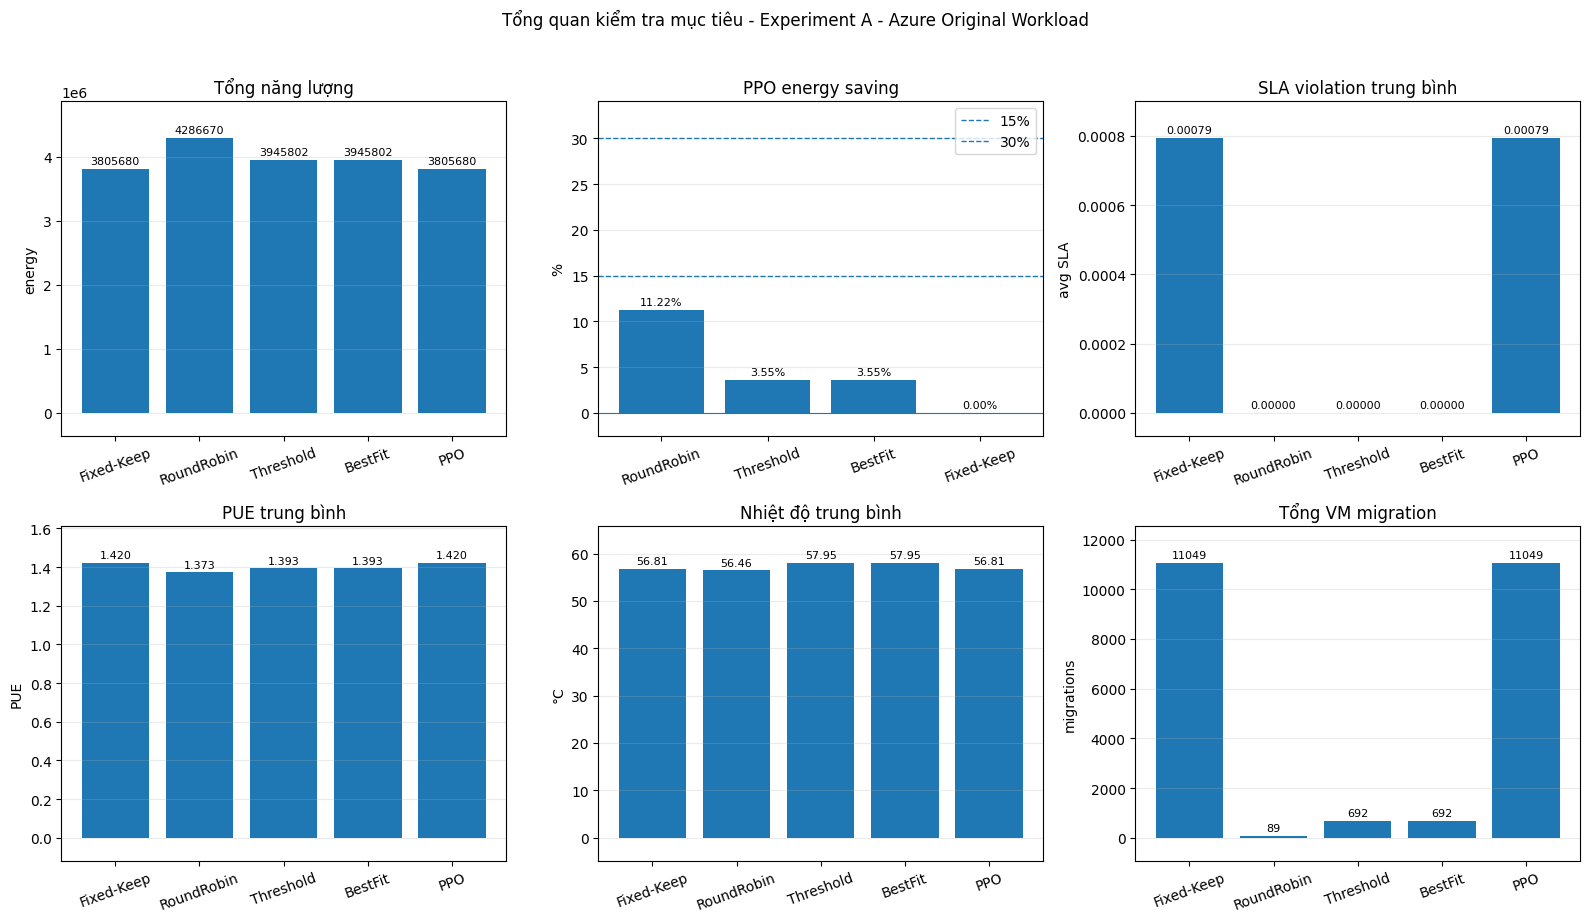

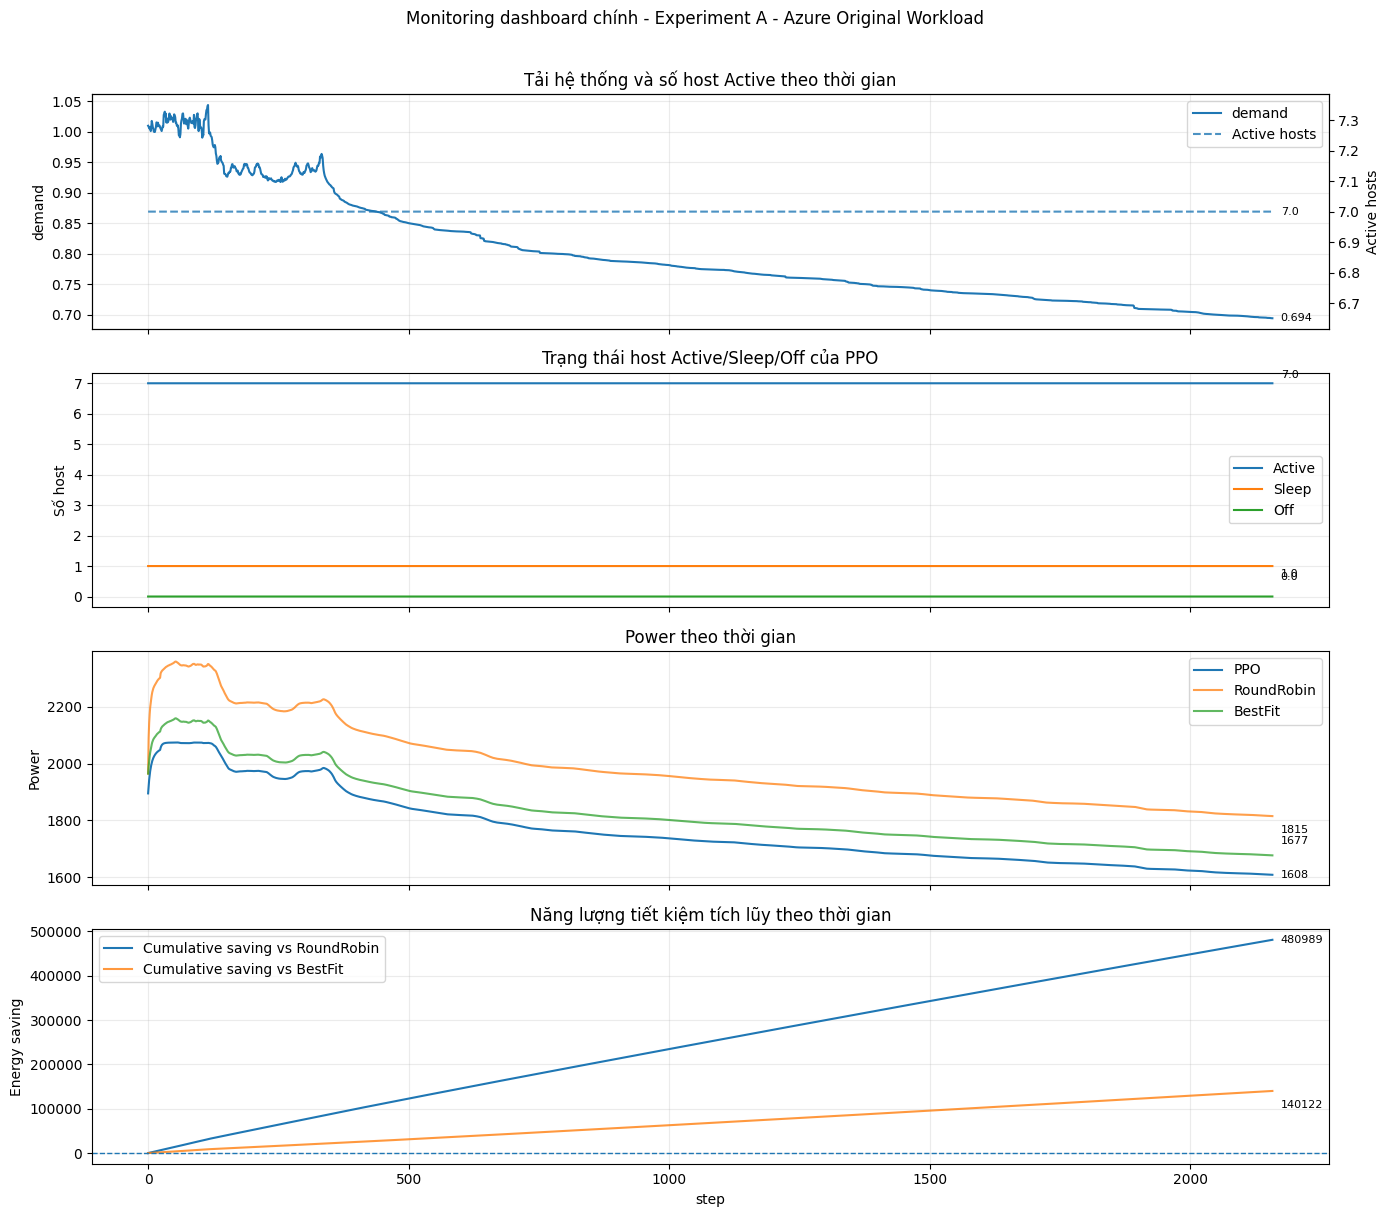

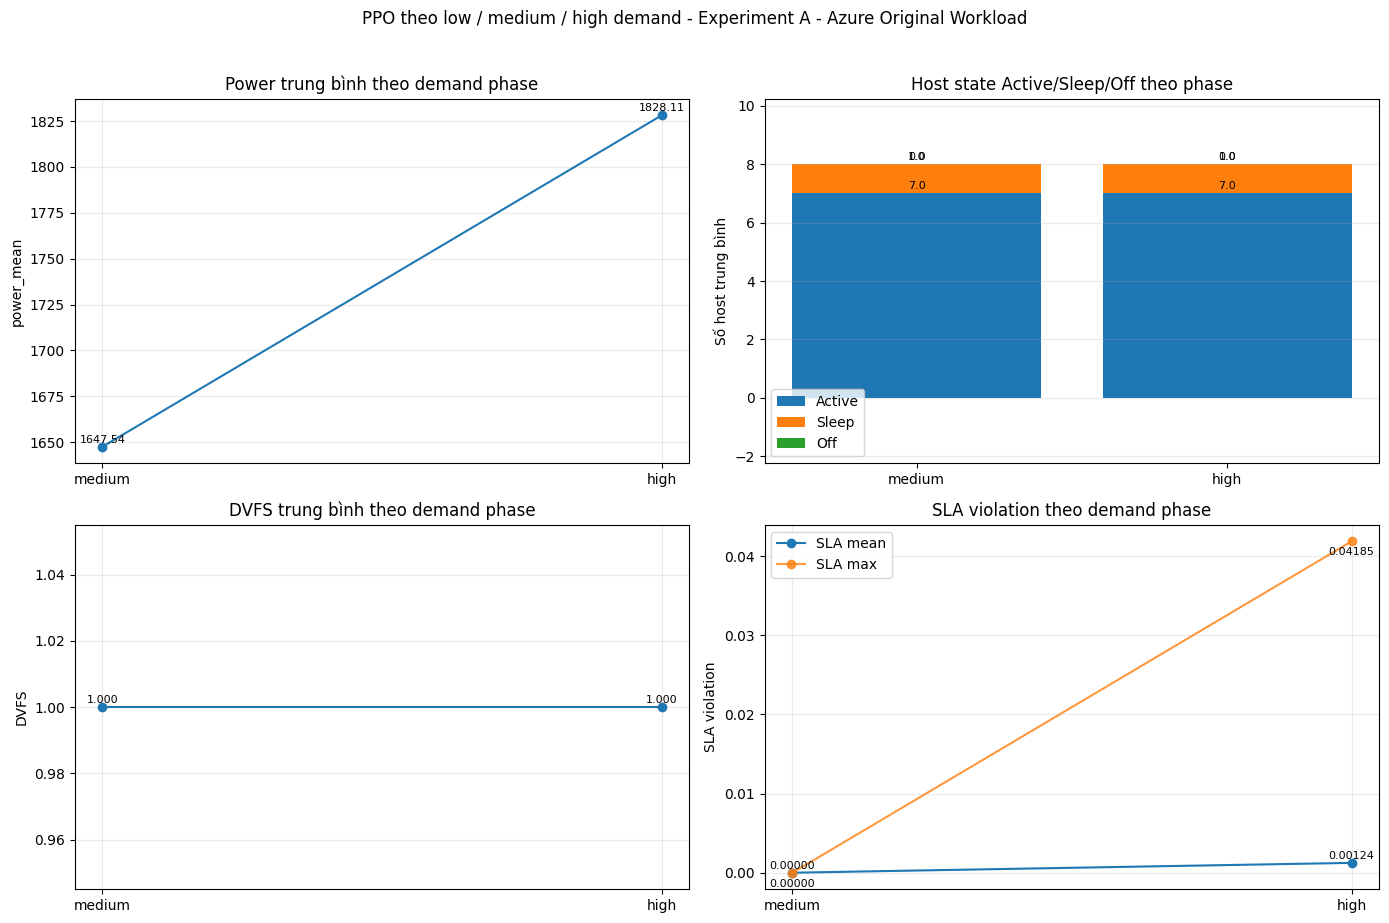

Đã lưu energy saving tại: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\outputs\original\run13_seed42_500000\summary\energy_saving_percentages.csv


,baseline,baseline_energy,ppo_energy,ppo_energy_saving_pct
1,RoundRobin,4.286670e+06,3.805680e+06,11.220587
2,Threshold,3.945802e+06,3.805680e+06,3.551156
3,BestFit,3.945802e+06,3.805680e+06,3.551156
0,Fixed-Keep,3.805680e+06,3.805680e+06,0.000000


Tóm tắt quan hệ demand - active hosts - energy saving theo phase:


,phase,count,demand_mean,active_hosts_mean,sleep_hosts_mean,off_hosts_mean,dvfs_mean,ppo_power_mean,sla_violation_mean,avg_temp_mean,energy_saved_vs_fixed_mean,energy_saved_vs_roundrobin_mean,energy_saved_vs_bestfit_mean
0,low,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,medium,782,0.721672,7.0,1.0,0.0,1.0,1647.541424,0.000000,54.818161,0.0,210.720440,67.343846
2,high,1377,0.843392,7.0,1.0,0.0,1.0,1828.106499,0.001243,57.940783,0.0,229.634054,63.513932


Phân tích PPO theo low / medium / high demand:


,phase,count,demand_mean,power_mean,pue_mean,sla_mean,sla_max,active_hosts_mean,sleep_hosts_mean,off_hosts_mean,dvfs_mean,avg_temp_mean,max_temp_mean,latency_penalty_mean,migrations_sum,migration_cost_sum
0,low,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000
1,medium,782,0.721672,1647.541424,1.400875,0.000000,0.000000,7.0,1.0,0.0,1.0,54.818161,64.711103,2.605319,0,0.000000
2,high,1377,0.843392,1828.106499,1.430387,0.001243,0.041847,7.0,1.0,0.0,1.0,57.940783,65.870684,3.000000,11049,256.625195


Artifact index:


,category,filename
0,figure,compare_avg_dvfs.png
1,figure,compare_avg_latency_penalty.png
2,figure,compare_avg_mean_host_age.png
3,figure,compare_avg_pue.png
4,figure,compare_avg_sla_violation.png
5,figure,compare_avg_temp.png
6,figure,compare_host_state_stacked.png
7,figure,compare_sla_violation_step_rate.png
8,figure,compare_total_energy.png
9,figure,compare_total_migrations_log.png


RUN_DIR: C:\Users\Minh Chau\Pictures\NT549_Q21_DRL_ERM_Cloud_migration_train_integrated\NT549.Q21-DRL-ERM-Cloud-main\azure_drl_beginner_project\azure_drl_beginner_project\outputs\original\run13_seed42_500000
Số artifact: 34


In [8]:
report_outputs = create_experiment_report(
    results_df=results_df,
    trace_dfs=trace_dfs,
    experiment_label=EXPERIMENT_LABEL,
    summary_dir=SUMMARY_DIR,
    figure_dir=FIGURE_DIR,
    trace_dir=TRACE_DIR,
    saving_csv=SAVING_CSV,
    show_main_figures=True,
)

saving_df = report_outputs["saving_df"]
relationship_by_phase = report_outputs["relationship_by_phase"]
phase_metrics = report_outputs["phase_metrics"]
artifact_index = report_outputs["artifact_index"]

print("Đã lưu energy saving tại:", SAVING_CSV)
display(saving_df)

print("Tóm tắt quan hệ demand - active hosts - energy saving theo phase:")
display(relationship_by_phase)

print("Phân tích PPO theo low / medium / high demand:")
display(phase_metrics)

print("Artifact index:")
display(artifact_index)

print("RUN_DIR:", RUN_DIR)
print("Số artifact:", len(artifact_index))


### Bước 9 - Kết luận nhanh sau khi chạy

Sau khi notebook chạy xong, kiểm tra các file trong:

```text
outputs/original/runXX_seedYY_ZZZZZZ/
```

Trong đó:

- `models/`: model PPO đã train.
- `traces/`: trace từng policy theo timestep.
- `summary/evaluation_results.csv`: bảng kết quả chính.
- `summary/energy_saving_percentages.csv`: PPO tiết kiệm bao nhiêu % so với baseline.
- `summary/ppo_phase_analysis.csv`: phân tích PPO theo low / medium / high demand.
- `summary/demand_active_energy_relationship.csv`: dữ liệu dashboard demand-active-energy.
- `summary/artifact_index.csv`: danh sách file artifact đã tạo.
- `figures/`: biểu đồ energy, PUE, SLA, DVFS, host states, temperature, migration, dashboard.

Cách đọc kết quả:

- Nếu PPO giữ SLA tốt nhưng energy saving thấp, có thể do Azure original workload thiếu low demand.
- Nếu PPO không sleep/off nhiều, không vội kết luận model sai; cần so sánh thêm với notebook multiphase.
- Chỉ claim mục tiêu giảm 15–30% energy nếu `energy_saving_percentages.csv` thật sự đạt mức đó so với RoundRobin/BestFit.
- Kết quả này là Experiment A: Azure Original Workload.
